# Progetto B1: Explainable AI & Adversarial Attacks

- Obiettivo: Addestrare una CNN custom e dimostrare di saper manipolare i gradienti sia per spiegare cosa la rete sta imparando (Grad-CAM), sia per tentare di ingannarla (Adversarial Attack).

### Specifiche:
1. Training: Addestrare una CNN (definita da voi, o pre-trainata) su un dataset come TinyImageNet, CIFAR-10 o subset di animali.
- Addestrate il sistema fino a convergenza.
- Mostrate le curve di apprendimento e risolvete ogni problema di underfitting, o overfitting. Presentare un sistema in cui gli addestramenti non sono completi è considerato come non averlo addestrato per nulla, in quanto non si possono fare considerazioni conclusive.
- Sicuramente avrete degli iper-parametri: progettate accuratamente gli esperimenti di validazione tendo conto della dimensione della rete, del numero di sample del dataset e altre condizioni al contorno. Le scelte progettuali non possono essere arbitrarie.
2. Grad-CAM: Implementare manualmente l'algoritmo Grad-CAM per visualizzare le heatmap di attivazione sulla classe predetta.
3. Attacco FGSM: Implementare il Fast Gradient Sign Method. Generare un adversarial example aggiungendo rumore impercettibile calcolato tramite il gradiente della loss rispetto all'input.
4. Analisi:
- Scegliere le metriche più opportune per testare il sistema
- Considerate gli attacchi alla vostra rete come attacchi “white-box”. Questa è la vostra baseline iniziale. Quindi esplorate l’efficacia di attacchi black-box su reti diverse addestrate per lo stesso task, o per task simili.
- Proporre, sulla base dell’analisi iniziale, strategie di miglioramento della strategia di attacco. Ipotizzare possibili contromisure e testarne l’efficacia.
- Visualizzare fianco a fianco: Immagine Originale + CAM, Immagine Avversaria + CAM. Commentare come cambia l'attenzione della rete.

### Hints Step-by-Step:
- Architettura suggerita: 4-5 blocchi Conv-ReLU-MaxPool seguiti da Global Average Pooling (importante per Grad-CAM) e un Linear layer.
- Grad-CAM: Usate register_forward_hook e register_backward_hook (o accedete a .grad) sull'ultimo layer convoluzionale per catturare feature maps () e gradienti ().
- FGSM: La formula è . Ricordate di fare input.requires_grad = True prima del forward pass per calcolare il gradiente rispetto all'immagine.

# Implementazione

## 1. Definisco una rete CNN e la addestro sul dataset CIFAR-10

## 1.1. Importare librerie
Importo le librerie Pythorch e Torchvision


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

## 1.2. Configurare il Device
Se disponibile uso la GPU per rendere più veloce l'addestramento


In [2]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Using device:", device)

Using device: mps


## 1.3. Caricamento e Preprocess Dataset
Creazione pipeline di Data augmentation e normalizzazione dei dati


In [3]:
#Media e Std calcolate specificamente su CIFAR-10
statsDataset = ((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)) 

#Media e Std standard
statsStandard =((0.5,0.5,0.5),(0.5,0.5,0.5))

transform_train_val = transforms.Compose([
    transforms.RandomCrop(32, padding=4), # Sposta l'immagine per non farla dipendere dal centro
    transforms.RandomHorizontalFlip(), # Raddoppia virtualmente il dataset specchiando le foto
    transforms.ToTensor(),
    transforms.Normalize(*statsDataset) # Centra i dati intorno allo zero (mu=0, std=1)
])
# Per Validation e Test NON usiamo augmentation (vogliamo dati reali)
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(*statsDataset) # Centra i dati intorno allo zero (mu=0, std=1)
])


Importazione trasformazione e suddivisione del dataset in train, validation e test

In [4]:
trainset_full = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform_train_val
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform_test
)

# utils per lo suddivisione random
from torch.utils.data import random_split

# Suddivisione in train e validation
train_size = int(0.8 * len(trainset_full))
val_size = len(trainset_full) - train_size

train_dataset, val_dataset = random_split(
    trainset_full,
    [train_size, val_size]
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

test_loader = DataLoader(testset, batch_size=128, shuffle=False)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(testset))

Train size: 40000
Validation size: 10000
Test size: 10000


Visualizzazione a campione di un'immagine da ogni dataset

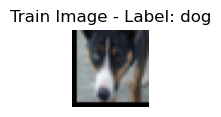

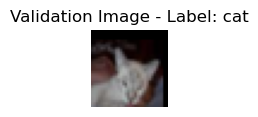

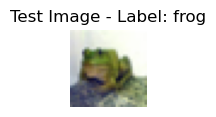

In [5]:
# importo le librerie per la denormalizzazione
import matplotlib.pyplot as plt
import numpy as np

# recupero i nomi delle classi dal dataset
classes = trainset_full.classes

# funzione per denormalizzare l'immagine
def imshow(img, statsDataset):
    # Trasforma mean e std in tensori per l'operazione vettoriale
    # (3, 1, 1) serve per fare il broadcasting sui canali dell'immagine
    mu = torch.tensor(statsDataset[0]).view(3, 1, 1)
    sigma = torch.tensor(statsDataset[1]).view(3, 1, 1)
    
    # Inversa della normalizzazione: (img * std) + mean
    img = img * sigma + mu
    
    # Clamp per evitare che errori di precisione portino i pixel fuori da [0, 1]
    img = torch.clamp(img, 0, 1)
    
    npimg = img.numpy()
    # Transpose da (C, H, W) a (H, W, C) per Matplotlib
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis("off")

import random

# -------- Visualizzazione di un'immagine dal Train set --------

train_idx = random.randint(0, len(train_dataset)-1)
train_img, train_label = train_dataset[train_idx]

plt.figure(figsize=(1,1))
imshow(train_img, statsDataset)
plt.title(f"Train Image - Label: {classes[train_label]}")
plt.show()


# -------- Visualizzazione di un'immagine dal Validation set --------

val_idx = random.randint(0, len(val_dataset)-1)
val_img, val_label = val_dataset[val_idx]

plt.figure(figsize=(1,1))
imshow(val_img, statsDataset)
plt.title(f"Validation Image - Label: {classes[val_label]}")
plt.show()


# -------- Visualizzazione di un'immagine dal Test set --------

test_idx = random.randint(0, len(testset)-1)
test_img, test_label = testset[test_idx]

plt.figure(figsize=(1,1))
imshow(test_img, statsDataset)
plt.title(f"Test Image - Label: {classes[test_label]}")
plt.show()

## 1.4. Definizione dell'Architettura CNN (Il Modello)
L'architettura segue il paradigma VGG-style (blocchi ripetuti) ma con l'aggiunta di Batch Normalization e Global Average Pooling, elementi moderni che facilitano l'addestramento e la spiegabilità (Grad-CAM).

In [6]:


class DeepCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(DeepCNN, self).__init__()
        
        # Helper per creare blocchi modulari Conv-BatchNorm-ReLU
        # BatchNorm2d: Normalizza le attivazioni all'interno del batch. 
        # Questo riduce l'Internal Covariate Shift e permette una convergenza più veloce.
        def conv_block(in_f, out_f, pool=False):
            layers = [
                nn.Conv2d(in_f, out_f, kernel_size=3, padding=1), # Padding=1 mantiene le dimensioni spaziali
                nn.BatchNorm2d(out_f), 
                nn.ReLU(inplace=True) # Inplace risparmia memoria video
            ]
            if pool: 
                # MaxPool2d: Riduce la dimensione spaziale di un fattore 2.
                # Serve per aumentare il campo ricettivo (receptive field) dei filtri successivi.
                layers.append(nn.MaxPool2d(2)) 
            return nn.Sequential(*layers)

        # Feature Extractor: Estrae pattern gerarchici (bordi -> forme -> oggetti)
        self.features = nn.Sequential(
            conv_block(3, 64),           # Output: 32x32 (stessa risoluzione dell'input CIFAR)
            conv_block(64, 128, True),   # Output: 16x16
            conv_block(128, 256, True),  # Output: 8x8
            conv_block(256, 512, True),  # Output: 4x4
            
            # Layer Target per Grad-CAM: l'ultimo layer convoluzionale
            # Questo strato contiene le informazioni semantiche più astratte.
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )
        
        # Global Average Pooling (GAP):
        # Invece di usare un layer 'Flatten' (che creerebbe milioni di parametri), 
        # facciamo la media di ogni mappa 4x4 ottenendo un singolo valore. 
        # Riduce drasticamente l'overfitting e collega direttamente le mappe alle classi (fondamentale per Grad-CAM).
        self.gap = nn.AdaptiveAvgPool2d(1) 
        
        # Classifier: Un unico strato lineare che mappa i 512 canali estratti alle 10 classi.
        self.classifier = nn.Linear(512, num_classes)

    def forward(self, x):
        # Passaggio dei dati attraverso i blocchi convoluzionali
        x = self.features(x)
        # Riduzione spaziale tramite GAP: da [Batch, 512, 4, 4] a [Batch, 512, 1, 1]
        x = self.gap(x)
        # Flattening necessario per il layer lineare: da [Batch, 512, 1, 1] a [Batch, 512]
        x = torch.flatten(x, 1)
        # Calcolo dei logit finali
        x = self.classifier(x)
        return x

# Creazione istanza
model = DeepCNN()
print(f"Modello inizializzato su: {device}")

Modello inizializzato su: mps


## 1.5. Ricerca degli iperparametri
Creazione di una funzione che serve a testare diverse combinazioni senza "sporcare" il training finale. Alleneremo alcune configurazioni in maniera casuale per un numero ridotto di epoche (es. 5) per identificare la più promettente.

In [7]:
import copy
import time
def random_search_engine(model_class, train_loader, val_loader, search_space, n_trials, n_epochs):
    """
    Esegue una ricerca casuale selezionando valori dalle liste fornite esternamente.
    
    Args:
        model_class: Classe della CNN (es. DeepCNN).
        search_space: Dizionario contenente le liste di valori per ogni iperparametro.
        n_trials: Numero di combinazioni casuali da testare.
        n_epochs: Numero di epoche per ogni test di screening.
    """
    best_acc = 0.0
    best_params = {}
    
    print(f"\n--- AVVIO RANDOM SEARCH SU {n_trials} TENTATIVI ---")

    for i in range(n_trials):
        start_trial = time.time()
        
        # --- ESTRAZIONE CASUALE DALLE LISTE ESTERNE ---
        # Usiamo random.choice per pescare direttamente dai valori definiti
        opt_name = random.choice(search_space['optimizers'])
        lr = random.choice(search_space['lr'])
        wd = random.choice(search_space['wd'])
        # Il momentum viene estratto solo se l'ottimizzatore selezionato è SGD
        mom = random.choice(search_space['mom']) if opt_name == 'SGD' else 0.0

        print(f"\n[Trial {i+1}] Config: {opt_name} | LR: {lr} | WD: {wd} | Mom: {mom}")
        
        # Inizializzazione di un nuovo modello per il test
        model = model_class().to(device)
        criterion = nn.CrossEntropyLoss()
        
        # Configurazione dell'ottimizzatore basata sulla scelta casuale
        if opt_name == 'Adam':
            optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
        else:
            optimizer = optim.SGD(model.parameters(), lr=lr, momentum=mom, weight_decay=wd)

        # Screening Rapido
        for epoch in range(n_epochs):
            model.train()
            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)
                optimizer.zero_grad()
                loss = criterion(model(images), labels)
                loss.backward()
                optimizer.step()
            
            # Validazione Live
            model.eval()
            correct, total = 0, 0
            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(device), labels.to(device)
                    out = model(images)
                    correct += out.argmax(1).eq(labels).sum().item()
                    total += labels.size(0)
            
            epoch_acc = 100 * correct / total
            print(f"  Epoca {epoch+1}/{n_epochs} | Val Acc: {epoch_acc:.2f}%")

        trial_time = time.time() - start_trial
        print(f"  [TIME] Trial completato in {trial_time:.2f}s")
        # --- AGGIORNAMENTO DEL MIGLIORE ---
        if epoch_acc > best_acc:
            best_acc = epoch_acc
            best_params = {'optimizer': opt_name, 'lr': lr, 'momentum': mom, 'weight_decay': wd, 'acc': epoch_acc}
    
    print(f"\n" + "="*60)
    print(f"RICERCA COMPLETATA. Migliori parametri: {best_params}")
    return best_params

# Parametri esterni
my_search_space = {
    'optimizers': ['Adam', 'SGD'],
    'lr': [1e-2, 1e-3, 1e-4],
    'wd': [1e-3, 1e-4, 1e-5],
    'mom': [0.8, 0.9, 0.95]
}
# Parametri di controllo
n_trials = 10 
n_epochs = 5

best_config = random_search_engine(DeepCNN, train_loader, val_loader, my_search_space, n_trials, n_epochs)


--- AVVIO RANDOM SEARCH SU 10 TENTATIVI ---

[Trial 1] Config: Adam | LR: 0.01 | WD: 0.001 | Mom: 0.0
  Epoca 1/5 | Val Acc: 33.80%
  Epoca 2/5 | Val Acc: 50.20%
  Epoca 3/5 | Val Acc: 54.43%
  Epoca 4/5 | Val Acc: 48.19%
  Epoca 5/5 | Val Acc: 50.21%
  [TIME] Trial completato in 357.70s

[Trial 2] Config: Adam | LR: 0.001 | WD: 0.0001 | Mom: 0.0
  Epoca 1/5 | Val Acc: 55.62%
  Epoca 2/5 | Val Acc: 68.34%
  Epoca 3/5 | Val Acc: 70.25%
  Epoca 4/5 | Val Acc: 74.73%
  Epoca 5/5 | Val Acc: 74.57%
  [TIME] Trial completato in 401.49s

[Trial 3] Config: Adam | LR: 0.001 | WD: 0.0001 | Mom: 0.0
  Epoca 1/5 | Val Acc: 51.18%
  Epoca 2/5 | Val Acc: 66.12%
  Epoca 3/5 | Val Acc: 73.75%
  Epoca 4/5 | Val Acc: 71.76%
  Epoca 5/5 | Val Acc: 75.81%
  [TIME] Trial completato in 422.97s

[Trial 4] Config: Adam | LR: 0.01 | WD: 1e-05 | Mom: 0.0
  Epoca 1/5 | Val Acc: 52.39%
  Epoca 2/5 | Val Acc: 60.45%
  Epoca 3/5 | Val Acc: 64.33%
  Epoca 4/5 | Val Acc: 76.30%
  Epoca 5/5 | Val Acc: 70.70%
  [TIME]

Salvare il dizionario per non dover rieseguire questa cella più volte

In [8]:
import json

# Definiamo il nome del file
config_filename = "best_hyperparameters.json"

# Salvataggio del dizionario su file
with open(config_filename, 'w') as f:
    json.dump(best_config, f, indent=4)

print(f"Configurazione salvata correttamente in: {config_filename}")

Configurazione salvata correttamente in: best_hyperparameters.json


Caricare il file

In [9]:
try:
    with open(config_filename, 'r') as f:
        best_config = json.load(f)
    print("--- Configurazione caricata da file ---")
    for key, value in best_config.items():
        print(f"{key}: {value}")
except:
    print("Attenzione: File di configurazione non trovato. È necessario eseguire la Random Search.")

--- Configurazione caricata da file ---
optimizer: Adam
lr: 0.01
momentum: 0.0
weight_decay: 1e-05
acc: 77.8


## 1.6. Addestramento Finale e Strategie di Regolarizzazione
Individuata la combinazione ottimale di iperparametri tramite la fase di Model Selection (Random Search), si procede all'addestramento definitivo del modello con:

- Learning Rate Scheduling (ReduceLROnPlateau) per ridurre dinamicamente la velocità di apprendimento quando la Validation Loss entra in una fase di stallo (plateau). 

- Early Stopping per risolvere il problema dell'Overfitting, è stato implementato un monitoraggio costante della funzione di perdita sul set di validazione. Se tale metrica smette di migliorare per un numero prefissato di epoche (patience), l'addestramento viene interrotto.

- Checkpointing via Deepcopy così che il sistema esegue una "fotografia" istantanea dei parametri ogni volta che viene registrato un nuovo record di Validation Loss, assicurando che il modello caricato a fine processo sia effettivamente il più performante.

In [ ]:
# Utilizziamo i parametri validati nella fase precedente
final_model = DeepCNN().to(device)
criterion = nn.CrossEntropyLoss()

if best_config['optimizer'] == 'Adam':
    optimizer = optim.Adam(final_model.parameters(), lr=best_config['lr'], weight_decay=best_config['weight_decay'])
else:
    optimizer = optim.SGD(final_model.parameters(), lr=best_config['lr'], 
                          momentum=best_config['momentum'], weight_decay=best_config['weight_decay'])

# --- Definizione dello Scheduler ---
# Fattore di riduzione 0.1 dopo 3 epoche di stallo
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

# --- Parametri di Controllo del Progetto ---
MAX_EPOCHS = 50          # Limite massimo di iterazioni
EARLY_STOP_PATIENCE = 7  # Tolleranza per la prevenzione dell'overfitting
best_val_loss = float('inf')
early_stop_counter = 0
best_model_wts = None    # Buffer per il miglior stato dei pesi

# Storico delle metriche per l'analisi post-addestramento
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print(f"--- Inizio Addestramento Finale ---")

for epoch in range(MAX_EPOCHS):
    # Fase di Training: aggiornamento dei pesi tramite backpropagation
    final_model.train()
    t_loss, t_correct, t_total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = final_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        t_loss += loss.item() * images.size(0)
        _, pred = outputs.max(1)
        t_total += labels.size(0)
        t_correct += pred.eq(labels).sum().item()

    # Fase di Validazione: valutazione della capacità di generalizzazione
    final_model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = final_model(images)
            v_l = criterion(outputs, labels)
            v_loss += v_l.item() * images.size(0)
            _, pred = outputs.max(1)
            v_total += labels.size(0)
            v_correct += pred.eq(labels).sum().item()

    # Calcolo medie e salvataggio storico
    avg_t_loss = t_loss / len(train_loader.dataset)
    avg_v_loss = v_loss / len(val_loader.dataset)
    acc_v = 100. * v_correct / v_total
    
    history['train_loss'].append(avg_t_loss)
    history['val_loss'].append(avg_v_loss)
    history['val_acc'].append(acc_v)

    print(f"Epoca {epoch+1:02d} | T-Loss: {avg_t_loss:.4f} | V-Loss: {avg_v_loss:.4f} | V-Acc: {acc_v:.2f}%")

    # Aggiornamento dinamico del Learning Rate
    scheduler.step(avg_v_loss)
    
    # Logica di Checkpointing ed Early Stopping
    if avg_v_loss < best_val_loss:
        best_val_loss = avg_v_loss
        # Utilizziamo deepcopy per isolare lo stato ottimale dalla memoria dinamica
        best_model_wts = copy.deepcopy(final_model.state_dict())
        torch.save(best_model_wts, 'best_model_checkpoint.pth')
        early_stop_counter = 0 
    else:
        early_stop_counter += 1
        if early_stop_counter >= EARLY_STOP_PATIENCE:
            print(f"\n[INFO] Early Stopping attivato: convergenza raggiunta.")
            break

# Ripristino del modello ottimale per le fasi successive
final_model.load_state_dict(best_model_wts)

## 1.7. Visualizzazione e Analisi delle Curve di Apprendimento
Qui genero due grafici affiancati:

- Loss History: Confronta la perdita sul set di addestramento e di validazione. L'incrocio o la divergenza di queste curve è l'indicatore principale della salute del modello.

- Validation Accuracy: Mostra l'evoluzione della precisione del modello nel tempo, evidenziando la stabilità raggiunta grazie allo Scheduling del Learning Rate.

In [ ]:
def plot_final_training_history(history):
    """
    Genera grafici per l'analisi della convergenza.
    """
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Inizializzazione della figura con due subplot
    plt.figure(figsize=(15, 6))

    # --- GRAFICO DELLA LOSS ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Training Loss', color='#1f77b4', linewidth=2)
    plt.plot(epochs, history['val_loss'], label='Validation Loss', color='#d62728', linewidth=2, linestyle='--')
    plt.title('Analisi della Convergenza (Loss)', fontsize=14, fontweight='bold')
    plt.xlabel('Epoche', fontsize=12)
    plt.ylabel('Cross Entropy Loss', fontsize=12)
    plt.legend(frameon=True, fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.6)

    # --- GRAFICO DELL'ACCURATEZZA ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['val_acc'], label='Validation Accuracy', color='#2ca02c', linewidth=2)
    plt.title('Evoluzione della Precisione (Accuracy)', fontsize=14, fontweight='bold')
    plt.xlabel('Epoche', fontsize=12)
    plt.ylabel('Accuratezza (%)', fontsize=12)
    plt.ylim(0, 100) # Scala fissa per una percezione corretta del miglioramento
    plt.legend(frameon=True, fontsize=11, loc='lower right')
    plt.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

# Esecuzione della visualizzazione
plot_final_training_history(history)